# Call cluster specific markers and save them for GO term analysis

This notebook is for calling GO terms and annotating cell types. If you have already created an annotation, you can skip this notebook.

In [1]:
import matplotlib.pyplot as plt

import numpy as np
import anndata as ad
import pandas as pd
import sys

sys.path.insert(0, '..')
import src as scit

In [2]:
adata = ad.read_h5ad('private/data/marek/combined.h5ad')

# Set active threshold at (bigger than) 0, as we already filtered low quality reads out, all remaining ones are good enough quality

lc_meth = scit.tl.make_layer_config(
    'meth_binary',
    in_obsm=False,
    feature_names=adata.var_names,#adata.uns['gene_names_acet'],
    feature_active_threshold=0
)
lc_acet = scit.tl.make_layer_config(
    'acet_binary',
    in_obsm=False,
    feature_names=adata.var_names,#adata.uns['gene_names_acet'],
    feature_active_threshold=0
)

In [3]:
scit.gr.knn(adata, 'X_multi_spectral')
g = scit.gr.neighbor_graph(adata)

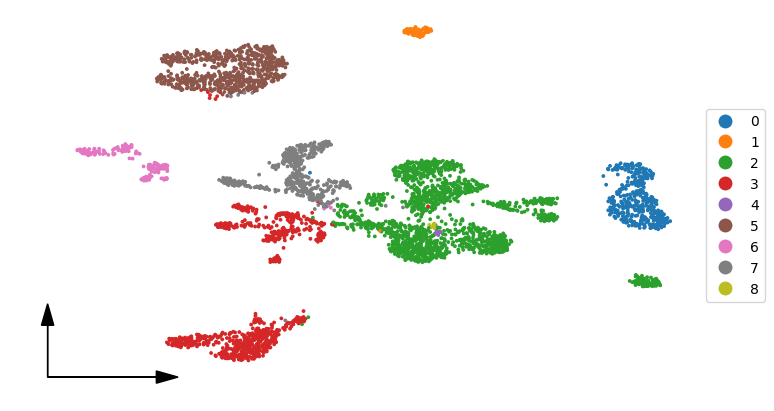

In [11]:
# Adjust resolution until you like the clustering (all large groups get their own color)
# Run multiple times (leiden is very random)
scit.set_defaults(figsize=(7,4))
scit.gr.leiden(adata, g, 0.03, random_seed=102)
scit.pl.embedding2d(adata, 'X_umap', 'leiden')

In [15]:
# Pick genes with minimum 1-3% of cells active,
# to make the computation easier

scit.tl.layer_pick_features(
    adata,
    lc_acet,
    after_binarization=True,
    filter_min = 150
)

Info: Picked 87041 features


In [16]:
m = scit.tl.enriched_in_group(
    adata,
    lc_acet,
    'leiden',
    binarize=True
)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 9/9 [03:14<00:00, 21.65s/it]


In [17]:
scit.tl.filter_top_markers(
    m,
    n_top=20,
    negative_markers=False
)

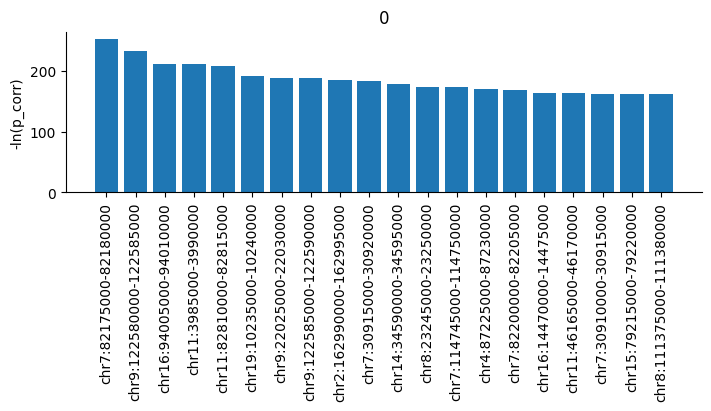

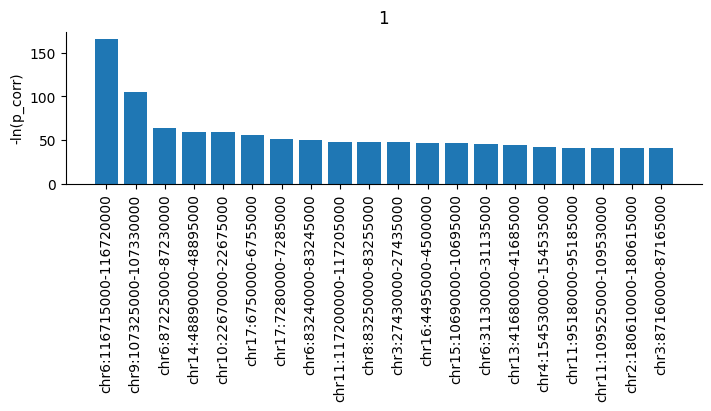

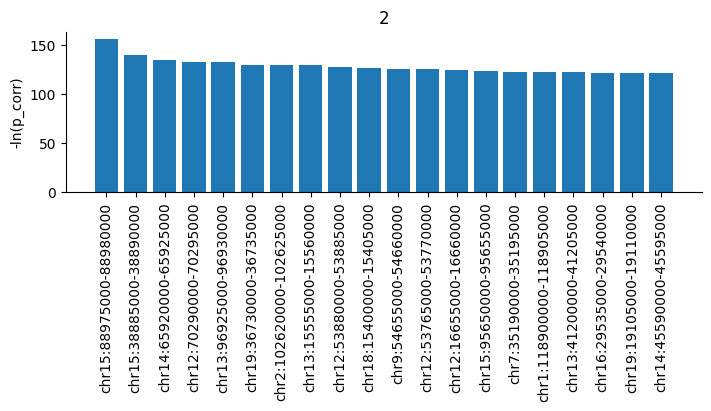

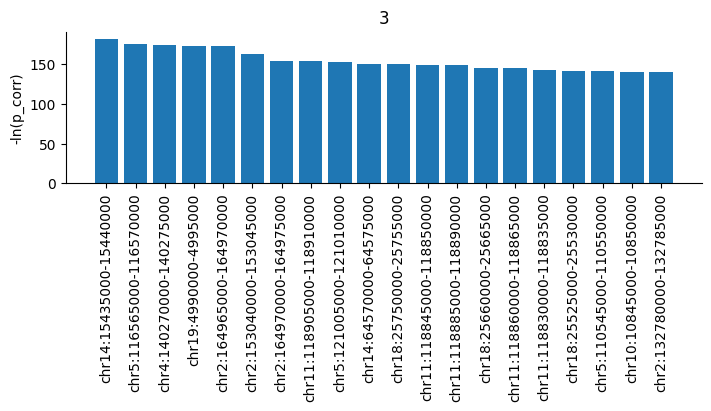

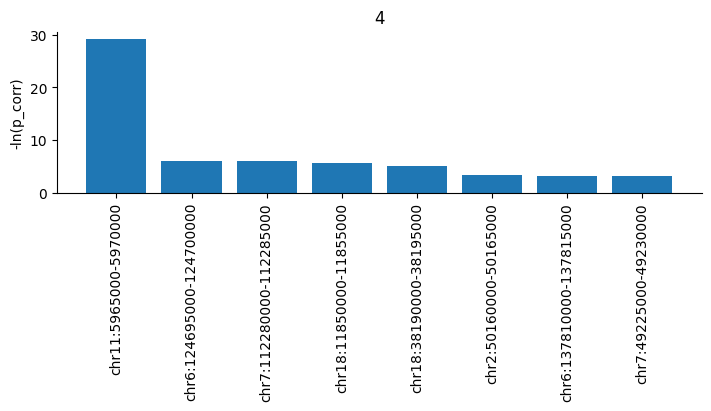

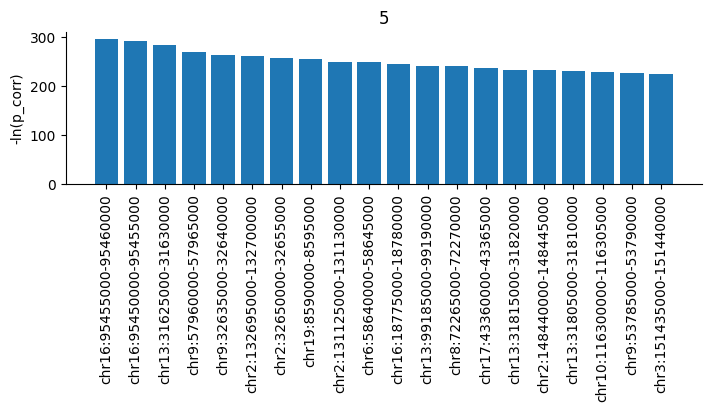

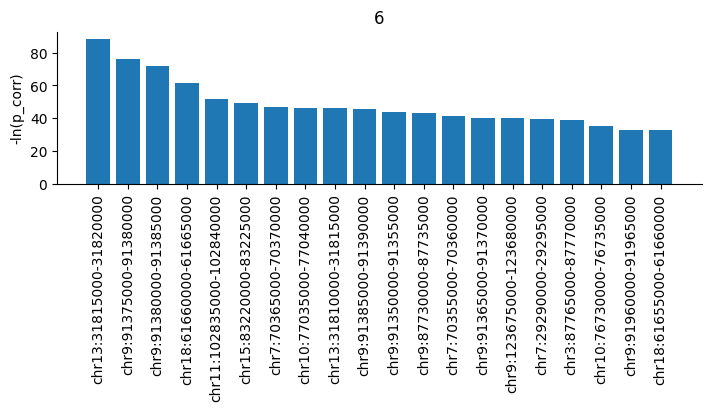

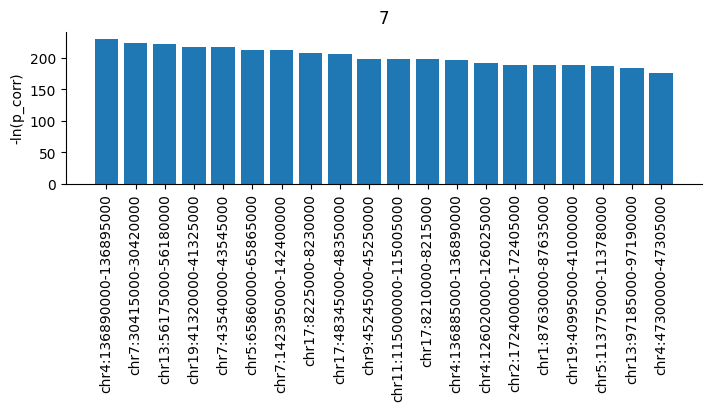

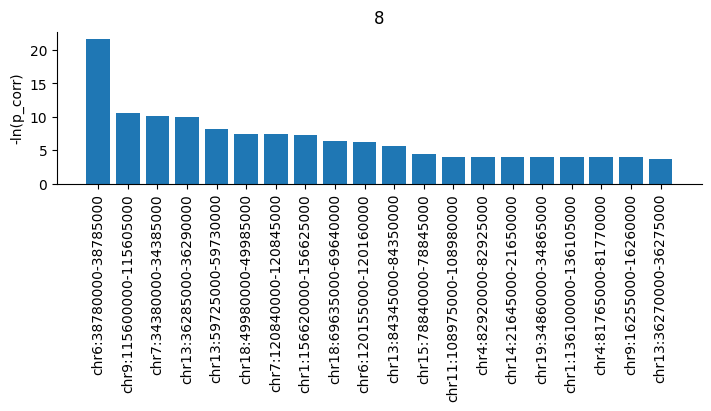

In [18]:
# White (no bar) means p value is zero

scit.pl.top_markers(m)

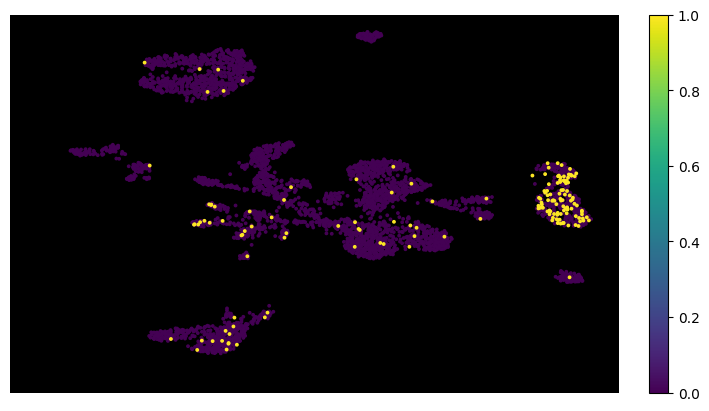

In [21]:
# Visualize marker:
marker_name = 'chr7:82175000-82180000'

scit.tl.layer_pick_features(adata, lc_acet, marker_name)
scit.tl.copy_to_obs(adata, lc_acet, binarize=True)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', black_background=True)

In [10]:
scit.tl.filter_top_markers(
    m,
    n_top=300,
    negative_markers=False
)

with open('private/data/top-markers.pickle', 'wb') as f:
    import pickle
    pickle.dump(m, f)

Info: [Ventral Nerve Cord] Some (1) p-values are extremely small (equal to zero)


In [ ]:
# Label cell clusters:

label_dict = {
    0: 'Celltype A',
    1: 'Celltype B',
    2: 'Celltype C',
    3: 'Celltype D',
    4: 'Celltype E',
    5: 'Celltype F',
    6: 'Celltype G',
    7: 'Celltype H',
    8: 'Celltype I'
}

import pandas as pd
adata.obs['label'] = pd.Categorical([label_dict[i] for i in adata.obs['leiden']])